In [1]:
import pandas as pd
import numpy as np
import sqlite3
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import category_encoders as ce
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
con = sqlite3.connect('alanya_property.db')

In [3]:
sql = 'SELECT * FROM alanya_property'

df = pd.read_sql_query(sql, con)

In [4]:
con.close()

In [5]:
df.head()

,price_€,rooms,area_sq_m,district,distance_to_sea_m,pr_per_sq_m,class
0,140000.0,2+1,100.0,Alanya(Center),550.0,1400.000000,comfort
1,82500.0,1+1,50.0,Alanya(Center),550.0,1650.000000,comfort
2,157500.0,1+1,68.0,Mahmutlar,600.0,2316.176471,comfort
3,86000.0,1+1,55.0,Kestel,627.0,1563.636364,comfort
4,74000.0,1+1,55.0,Mahmutlar,1500.0,1345.454545,comfort


In [6]:
df_copy = df.copy()

In [7]:
# Обов'язково видаляється перед навчанням, щоб запобігти витоку даних,
# оскільки, маючи площу і вартість квадратного метру, ми маємо і ціну.

df_copy.drop('pr_per_sq_m', axis=1, inplace=True)

In [8]:
df_copy['rooms'].value_counts()

rooms
1+1    728
2+1    457
3+1    188
4+1     74
3+2     12
5+1     11
1+0      9
4+2      5
2+2      1
Name: count, dtype: int64

In [9]:
rooms_mapping = {
    '1+1': 2,
    '2+1': 3,
    '3+1': 4,
    '4+1': 5,
    '3+2': 5,
    '5+1': 6,
    '1+0': 1,
    '4+2': 6,
    '2+2': 4
}

df_copy['count_rooms'] = df_copy['rooms'].map(rooms_mapping)

In [10]:
df_copy['avg_room_size'] = df_copy['area_sq_m'] / df_copy['count_rooms']

In [11]:
df_copy['area_distance_ratio'] = df_copy['area_sq_m'] / (df_copy['distance_to_sea_m'] + 1)

In [12]:
df_copy.head()

,price_€,rooms,area_sq_m,district,distance_to_sea_m,class,count_rooms,avg_room_size,area_distance_ratio
0,140000.0,2+1,100.0,Alanya(Center),550.0,comfort,3,33.333333,0.181488
1,82500.0,1+1,50.0,Alanya(Center),550.0,comfort,2,25.000000,0.090744
2,157500.0,1+1,68.0,Mahmutlar,600.0,comfort,2,34.000000,0.113145
3,86000.0,1+1,55.0,Kestel,627.0,comfort,2,27.500000,0.087580
4,74000.0,1+1,55.0,Mahmutlar,1500.0,comfort,2,27.500000,0.036642


In [13]:
df_copy.drop('rooms', axis=1, inplace=True)

In [14]:
Q1 = df_copy['price_€'].quantile(0.25)
Q3 = df_copy['price_€'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df_copy[(df_copy['price_€'] >= lower_bound) & (df_copy['price_€'] <= upper_bound)]

In [15]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1378 entries, 0 to 1483
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   price_€              1378 non-null   float64
 1   area_sq_m            1378 non-null   float64
 2   district             1378 non-null   object 
 3   distance_to_sea_m    1378 non-null   float64
 4   class                1378 non-null   object 
 5   count_rooms          1378 non-null   int64  
 6   avg_room_size        1378 non-null   float64
 7   area_distance_ratio  1378 non-null   float64
dtypes: float64(5), int64(1), object(2)
memory usage: 96.9+ KB


In [16]:
df_clean.describe()

,price_€,area_sq_m,distance_to_sea_m,count_rooms,avg_room_size,area_distance_ratio
count,1378.000000,1378.000000,1378.000000,1378.000000,1378.000000,1378.000000
mean,155944.429608,91.145864,923.463716,2.664006,32.700653,0.371323
std,68061.589190,48.983981,853.876375,0.879623,7.865694,1.707795
min,46500.000000,34.000000,0.000000,1.000000,17.000000,0.010997
25%,104925.000000,55.000000,300.000000,2.000000,27.500000,0.057311
50%,140000.000000,70.000000,600.000000,2.000000,30.500000,0.124938
75%,194875.000000,115.000000,1400.000000,3.000000,36.666667,0.315059
max,367500.000000,286.000000,6000.000000,6.000000,83.000000,60.000000


In [17]:
X = df_clean.drop('price_€', axis=1)
y = np.log1p(df_clean['price_€']) # np.expm1
X.shape, y.shape

((1378, 7), (1378,))

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=5)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((964, 7), (414, 7), (964,), (414,))

In [19]:
num_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_features = X.select_dtypes(include=["object"]).columns.tolist()

In [20]:
scaler = StandardScaler()

In [21]:
X_train[num_features] = scaler.fit_transform(X_train[num_features])

In [22]:
X_test[num_features] = scaler.transform(X_test[num_features])

In [23]:
X_train.head()

,area_sq_m,district,distance_to_sea_m,class,count_rooms,avg_room_size,area_distance_ratio
1271,-0.761475,Mahmutlar,-0.740894,comfort,-0.768653,-0.730935,-0.253561
720,0.372712,Alanya(Center),-0.260128,econom,0.366081,0.522348,-0.293029
623,0.372712,Mahmutlar,0.701403,comfort,0.366081,0.522348,-0.439846
1231,-0.761475,Mahmutlar,0.701403,comfort,-0.768653,-0.730935,-0.505339
1013,0.372712,Oba,-0.861085,comfort,0.366081,0.522348,0.392204


In [24]:
X_test.head()

,area_sq_m,district,distance_to_sea_m,class,count_rooms,avg_room_size,area_distance_ratio
528,-0.174128,Mahmutlar,-0.620702,econom,-1.903387,6.529463,-0.205144
1121,0.514485,Alanya(Center),-0.740894,comfort,0.366081,0.824864,0.113860
465,-0.741222,Demirtaş,0.340828,econom,-0.768653,-0.666110,-0.488102
1003,-0.923501,Avsallar,-0.260128,lux,-0.768653,-1.249535,-0.453299
835,-0.741222,Avsallar,-0.019746,comfort,-0.768653,-0.666110,-0.461334


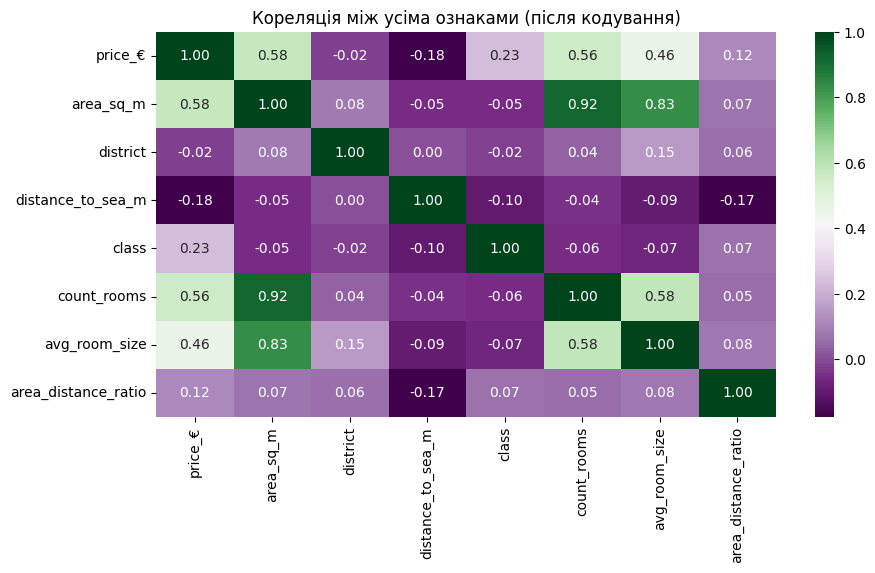

In [25]:
df_enc = df_clean.copy()

for col in df_enc.select_dtypes(include=["object"]).columns:
    df_enc[col] = df_enc[col].astype("category").cat.codes

corr_matrix = df_enc.corr()
plt.figure(figsize=(10, 5))
sns.heatmap(corr_matrix, annot=True, cmap="PRGn", fmt=".2f")
plt.title("Кореляція між усіма ознаками (після кодування)")
plt.show()

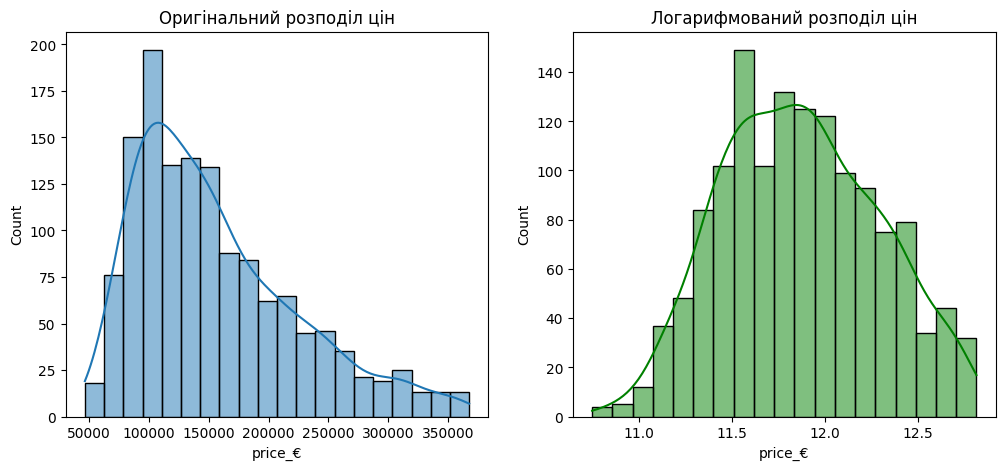

In [26]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_clean['price_€'], kde=True)
plt.title("Оригінальний розподіл цін")

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df_clean['price_€']), kde=True, color='green')
plt.title("Логарифмований розподіл цін")
plt.show()

In [27]:
encoder = ce.TargetEncoder(cols=cat_features, smoothing=10)

In [28]:
X_train_enc = encoder.fit_transform(X_train, y_train)

In [29]:
X_test_enc = encoder.transform(X_test)

In [30]:
X_train_enc.head()

,area_sq_m,district,distance_to_sea_m,class,count_rooms,avg_room_size,area_distance_ratio
1271,-0.761475,11.809745,-0.740894,11.810917,-0.768653,-0.730935,-0.253561
720,0.372712,12.076974,-0.260128,11.759980,0.366081,0.522348,-0.293029
623,0.372712,11.809745,0.701403,11.810917,0.366081,0.522348,-0.439846
1231,-0.761475,11.809745,0.701403,11.810917,-0.768653,-0.730935,-0.505339
1013,0.372712,11.908959,-0.861085,11.810917,0.366081,0.522348,0.392204


In [31]:
X_test_enc.head()

,area_sq_m,district,distance_to_sea_m,class,count_rooms,avg_room_size,area_distance_ratio
528,-0.174128,11.809745,-0.620702,11.759980,-1.903387,6.529463,-0.205144
1121,0.514485,12.076974,-0.740894,11.810917,0.366081,0.824864,0.113860
465,-0.741222,11.718167,0.340828,11.759980,-0.768653,-0.666110,-0.488102
1003,-0.923501,11.546282,-0.260128,12.147889,-0.768653,-1.249535,-0.453299
835,-0.741222,11.546282,-0.019746,11.810917,-0.768653,-0.666110,-0.461334


In [32]:
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [33]:
models = {
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=6, random_state=5),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=5)
}

In [34]:
for name, model in models.items():
    model.fit(X_train_enc, y_train)
    predictions = model.predict(X_test_enc)

    y_true = np.expm1(y_test)
    y_pred = np.expm1(predictions)
    
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f'=== {name} ==='
          f'\nMAE (Середня помилка): {mae:.2f} €'
          f'\nR² Score (Точність): {r2:.4f}\n')

=== Ridge Regression ===
MAE (Середня помилка): 70518.31 €
R² Score (Точність): -153.5602

=== Decision Tree ===
MAE (Середня помилка): 25239.24 €
R² Score (Точність): 0.7452

=== Random Forest ===
MAE (Середня помилка): 23709.56 €
R² Score (Точність): 0.7653



In [35]:
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

In [36]:
models_boosting = {
    "XGBoost": xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=5),
    "LightGBM": lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=5, verbose=-1),
}

In [37]:
for name, model in models_boosting.items():
    model.fit(X_train_enc, y_train)
    
    predictions = model.predict(X_test_enc)

    y_true = np.expm1(y_test)
    y_pred = np.expm1(predictions)
    
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f'=== {name} ==='
      f'\nMAE (Середня помилка): {mae:.2f} €'
      f'\nR² Score (Точність): {r2:.4f}\n')

=== XGBoost ===
MAE (Середня помилка): 23498.08 €
R² Score (Точність): 0.7599

=== LightGBM ===
MAE (Середня помилка): 23065.69 €
R² Score (Точність): 0.7815



In [38]:
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(X, y, test_size=0.3, random_state=5)
X_train_cat.shape, X_test_cat.shape, y_train_cat.shape, y_test_cat.shape

((964, 7), (414, 7), (964,), (414,))

In [39]:
X_train_cat.head()

,area_sq_m,district,distance_to_sea_m,class,count_rooms,avg_room_size,area_distance_ratio
1271,54.0,Mahmutlar,300.0,comfort,2,27.000000,0.179402
720,110.0,Alanya(Center),700.0,econom,3,36.666667,0.156919
623,110.0,Mahmutlar,1500.0,comfort,3,36.666667,0.073284
1231,54.0,Mahmutlar,1500.0,comfort,2,27.000000,0.035976
1013,110.0,Oba,200.0,comfort,3,36.666667,0.547264


In [40]:
cat_model = cb.CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    l2_leaf_reg=10,
    depth=2,
    cat_features=cat_features,
    random_state=5,
    verbose=0
)

In [41]:
cat_model.fit(X_train_cat, y_train_cat,
             eval_set=(X_test_cat, y_test_cat),
             early_stopping_rounds=30,
             plot=True)

predictions_cat = cat_model.predict(X_test_cat)

y_true_cat = np.expm1(y_test_cat)
y_pred_cat = np.expm1(predictions_cat)

mae_cat = mean_absolute_error(y_true_cat, y_pred_cat)
r2_cat = r2_score(y_true_cat, y_pred_cat)

print(f'=== CatBoost ==='
  f'\nMAE (Середня помилка): {mae_cat:.2f} €'
  f'\nR² Score (Точність): {r2_cat:.4f}\n')

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

=== CatBoost ===
MAE (Середня помилка): 22413.71 €
R² Score (Точність): 0.8006



In [42]:
from sklearn.metrics import mean_absolute_percentage_error

In [43]:
mape = mean_absolute_percentage_error(y_true_cat, y_pred_cat)
print(f"Реальна середня помилка моделі: {mape * 100:.2f}%")

Реальна середня помилка моделі: 14.35%


Графік залишків (Residuals Plot)

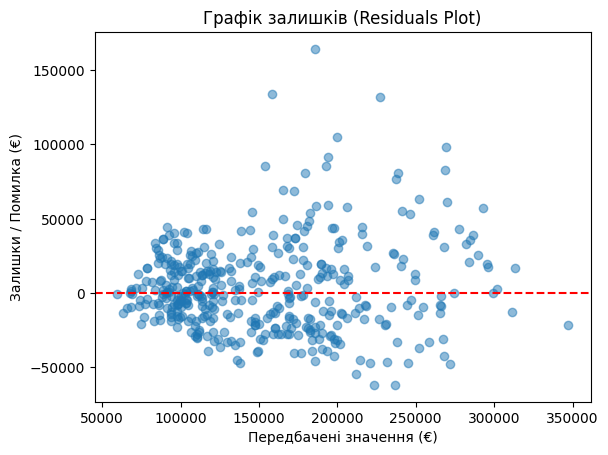

In [44]:
residuals = y_true_cat - y_pred_cat
plt.scatter(y_pred_cat, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Передбачені значення (€)')
plt.ylabel('Залишки / Помилка (€)')
plt.title('Графік залишків (Residuals Plot)')
plt.show()

Реальні ціни проти Передбачених (Actual vs. Predicted Plot)

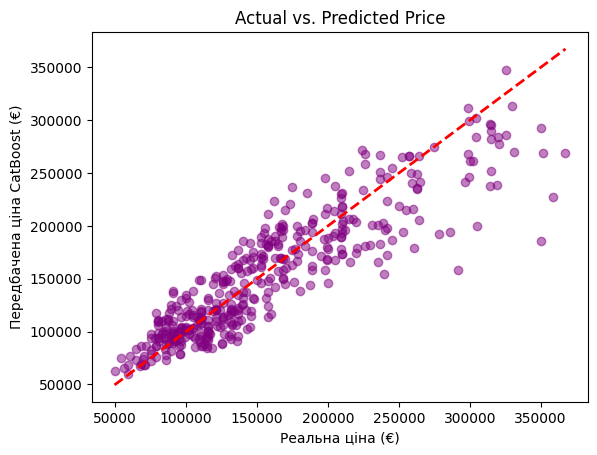

In [45]:
plt.scatter(y_true_cat, y_pred_cat, alpha=0.5, color='purple')
plt.plot([y_true_cat.min(), y_true_cat.max()], [y_true_cat.min(), y_true_cat.max()], 'r--', lw=2)
plt.xlabel('Реальна ціна (€)')
plt.ylabel('Передбачена ціна CatBoost (€)')
plt.title('Actual vs. Predicted Price')
plt.show()

In [46]:
joblib.dump(cat_model, 'cat_model.joblib')

['cat_model.joblib']